# Investigação: Energy Drink/E-commerce e Flavored Water/E-commerce — MAPE vs WAPE

Os dois SKU-canal que ficaram com accuracy negativa em todo o bake-off anterior (LightGBM, XGBoost, GAM, Stacked -- todos) têm um traço em comum: **volume absoluto baixo e volátil** (mediana ~1,1-1,4 toneladas, mínimo histórico ~0,12-0,13 toneladas). Isso é um cenário clássico onde o **MAPE** (que divide o erro pelo valor real, semana a semana) explode nas semanas de volume baixo, mesmo com erro absoluto pequeno.

Este notebook recalcula a accuracy desses dois SKU-canal usando **WAPE** (que soma erros e volumes antes de dividir, pesando naturalmente por volume) e compara com o MAPE que já tínhamos.

## MAPE vs WAPE — recapitulando

- **MAPE** = média dos erros percentuais semana a semana -- toda semana pesa igual, não importa o volume
- **WAPE** = soma dos erros absolutos / soma dos volumes reais -- semanas de maior volume pesam mais, semanas de volume baixo não conseguem distorcer o resultado sozinhas

> Requisitos: `pip install lightgbm pandas numpy matplotlib openpyxl`


## Libraries, Load Data, Feature Engineering

In [1]:
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt

DATA_PATH = "Business_Case_Data_Set.xlsx"

CATEGORY_MAP = {
    "Natural Juice 1L": "Beverages", "Flavored Water 500ml": "Beverages", "Energy Drink 350ml": "Beverages",
    "Whole Grain Crackers 200g": "Snacks", "Cereal Bar 50g": "Snacks",
}

xl = pd.ExcelFile(DATA_PATH)
ext = xl.parse("Table 1 - External Variables")
actual = xl.parse("Table 2 - Sell In")
raw = ext.merge(actual, on=["Week", "Product", "Channel"], how="inner")
raw["Week"] = pd.to_datetime(raw["Week"])
raw["Category"] = raw["Product"].map(CATEGORY_MAP)
raw = raw.sort_values(["Product", "Channel", "Week"]).reset_index(drop=True)
raw["Week_Index"] = raw.groupby(["Product", "Channel"]).cumcount()

TARGET_COL = "Sell_In_Tons"
FEATURE_COLS = [
    "Price_per_kg_USD", "Numeric_Distribution", "Weighted_Distribution",
    "Advertising_Investment_USD", "Promotion_Investment_USD", "Promo_Flag",
    "Lag_1w", "Lag_4w", "Rolling_Mean_4w", "Rolling_Std_4w",
    "Price_Change_Pct", "Month_Sin", "Month_Cos", "Holiday_Flag", "Interaction_Price_Promo",
]
HOLDOUT_QUANTILE = 0.85

SKU_LEVEL_PARAMS = dict(
    n_estimators=500, learning_rate=0.1, max_depth=4, num_leaves=15,
    min_child_samples=10, subsample=0.8, colsample_bytree=0.8,
    reg_alpha=1.0, reg_lambda=1.0, min_split_gain=0.0,
    boosting_type="gbdt", objective="regression", metric="mape",
    random_state=42, n_jobs=-1, verbose=-1,
)


def engineer_features(df):
    df = df.copy()
    df["Promo_Flag"] = df["Promotion_Type"].notna().astype(int)
    g_target = df.groupby(["Product", "Channel"])[TARGET_COL]
    df["Lag_1w"] = g_target.shift(1)
    df["Lag_4w"] = g_target.shift(4)
    shifted = g_target.shift(1)
    grouped_shifted = shifted.groupby([df["Product"], df["Channel"]])
    df["Rolling_Mean_4w"] = grouped_shifted.rolling(4).mean().reset_index(level=[0, 1], drop=True)
    df["Rolling_Std_4w"] = grouped_shifted.rolling(4).std().reset_index(level=[0, 1], drop=True)
    df["Price_Change_Pct"] = df.groupby(["Product", "Channel"])["Price_per_kg_USD"].pct_change()
    month = df["Week"].dt.month
    df["Month_Sin"] = np.sin(2 * np.pi * month / 12)
    df["Month_Cos"] = np.cos(2 * np.pi * month / 12)
    df["Holiday_Flag"] = 0
    df["Interaction_Price_Promo"] = df["Price_per_kg_USD"] * df["Promo_Flag"]
    return df.dropna(subset=FEATURE_COLS + [TARGET_COL]).reset_index(drop=True)


def time_split(df):
    cutoff = df.groupby(["Product", "Channel"])["Week"].transform(
        lambda x: x.quantile(HOLDOUT_QUANTILE, interpolation="nearest")
    )
    return df[df["Week"] <= cutoff].copy(), df[df["Week"] > cutoff].copy()


df = engineer_features(raw)
train, test = time_split(df)
print(f"{len(df)} linhas apos feature engineering | Treino: {len(train)} | Teste: {len(test)}")


2280 linhas apos feature engineering | Treino: 1935 | Teste: 345


## Treinar SKU-level LightGBM (todas as 15 combinações, para contexto)

Reaproveitamos a arquitetura vencedora (SKU-level) já validada no notebook de Experimentos.

In [2]:
def train_all_sku_channels(train_df, params, feature_cols=None):
    feature_cols = feature_cols or FEATURE_COLS
    models = {}
    for (product, channel), sub in train_df.groupby(["Product", "Channel"]):
        if len(sub) < 15:
            continue
        X, y = sub[feature_cols], sub[TARGET_COL]
        model = lgb.LGBMRegressor(**params)
        model.fit(X, y)
        models[(product, channel)] = model
    return models


sku_level_models = train_all_sku_channels(train, SKU_LEVEL_PARAMS)
print(f"{len(sku_level_models)} modelos SKU-level treinados.")


15 modelos SKU-level treinados.


## Backtest recursivo (mesma metodologia já validada)

In [3]:
def recursive_backtest_sku(model, raw_df, product, channel, feature_cols=None):
    feature_cols = feature_cols or FEATURE_COLS
    sub = raw_df[(raw_df["Product"] == product) & (raw_df["Channel"] == channel)].sort_values("Week").reset_index(drop=True)
    cutoff = sub["Week"].quantile(HOLDOUT_QUANTILE, interpolation="nearest")
    train_idx = sub.index[sub["Week"] <= cutoff].tolist()
    test_idx = sub.index[sub["Week"] > cutoff].tolist()
    if len(test_idx) < 2 or len(train_idx) < 4:
        return pd.DataFrame()

    history = sub.loc[train_idx, TARGET_COL].tolist()
    rows = []
    for horizon, idx in enumerate(test_idx, start=1):
        row = sub.loc[idx]
        promo_flag = int(pd.notna(row["Promotion_Type"]))
        prev_price = sub.loc[idx - 1, "Price_per_kg_USD"] if (idx - 1) in sub.index else np.nan
        price_change_pct = ((row["Price_per_kg_USD"] - prev_price) / prev_price
                             if pd.notna(prev_price) and prev_price != 0 else np.nan)
        month = row["Week"].month
        feat = {
            "Price_per_kg_USD": row["Price_per_kg_USD"], "Numeric_Distribution": row["Numeric_Distribution"],
            "Weighted_Distribution": row["Weighted_Distribution"], "Advertising_Investment_USD": row["Advertising_Investment_USD"],
            "Promotion_Investment_USD": row["Promotion_Investment_USD"], "Promo_Flag": promo_flag,
            "Lag_1w": history[-1], "Lag_4w": history[-4] if len(history) >= 4 else history[0],
            "Rolling_Mean_4w": float(np.mean(history[-4:])),
            "Rolling_Std_4w": float(np.std(history[-4:], ddof=1)) if len(history[-4:]) > 1 else 0.0,
            "Price_Change_Pct": price_change_pct, "Month_Sin": np.sin(2 * np.pi * month / 12),
            "Month_Cos": np.cos(2 * np.pi * month / 12), "Holiday_Flag": 0,
            "Interaction_Price_Promo": row["Price_per_kg_USD"] * promo_flag,
        }
        X_row = pd.DataFrame([feat])[feature_cols]
        pred = float(model.predict(X_row)[0])
        rows.append({"Product": product, "Channel": channel, "Week": row["Week"], "Horizon": horizon,
                      "Actual": row[TARGET_COL], "Predicted": pred})
        history.append(pred)

    result = pd.DataFrame(rows)
    result["APE"] = (result["Actual"] - result["Predicted"]).abs() / result["Actual"]
    return result


all_results = []
for (product, channel), model in sku_level_models.items():
    r = recursive_backtest_sku(model, raw, product, channel)
    if len(r):
        all_results.append(r)
recursive_results = pd.concat(all_results, ignore_index=True)
print(f"Backtest recursivo concluido: {len(recursive_results)} previsoes.")


Backtest recursivo concluido: 345 previsoes.


## Comparando MAPE vs WAPE, para todas as 15 combinações

Foco nos dois casos problemáticos, mas calculamos para todas para dar contexto.

In [4]:
def accuracy_mape_by_sku(recursive_df):
    return recursive_df.groupby(["Product", "Channel"]).apply(
        lambda g: 1 - g["APE"].mean()
    ).reset_index(name="Accuracy_MAPE")


def accuracy_wape_by_sku(recursive_df):
    def wape(g):
        return 1 - (g["Actual"] - g["Predicted"]).abs().sum() / g["Actual"].sum()
    return recursive_df.groupby(["Product", "Channel"]).apply(wape).reset_index(name="Accuracy_WAPE")


mape_table = accuracy_mape_by_sku(recursive_results)
wape_table = accuracy_wape_by_sku(recursive_results)
comparison = mape_table.merge(wape_table, on=["Product", "Channel"])
comparison["Delta_pp"] = (comparison["Accuracy_WAPE"] - comparison["Accuracy_MAPE"]) * 100
comparison = comparison.sort_values("Delta_pp", ascending=False)

print(comparison.to_string(index=False))
comparison.to_csv("mape_vs_wape_by_sku.csv", index=False)


                  Product      Channel  Accuracy_MAPE  Accuracy_WAPE   Delta_pp
     Flavored Water 500ml   E-commerce      -0.567194       0.467793 103.498701
       Energy Drink 350ml   E-commerce      -0.361844       0.373699  73.554338
     Flavored Water 500ml  Traditional       0.604621       0.760562  15.594066
         Natural Juice 1L Supermarkets       0.674157       0.754800   8.064299
     Flavored Water 500ml Supermarkets       0.670090       0.744627   7.453689
           Cereal Bar 50g  Traditional       0.492472       0.536038   4.356622
Whole Grain Crackers 200g Supermarkets       0.717843       0.751060   3.321637
       Energy Drink 350ml Supermarkets       0.773697       0.798518   2.482016
Whole Grain Crackers 200g  Traditional       0.469790       0.491818   2.202847
           Cereal Bar 50g   E-commerce       0.832475       0.848289   1.581417
       Energy Drink 350ml  Traditional       0.816507       0.831193   1.468555
Whole Grain Crackers 200g   E-commerce  

## Foco nos dois SKU-canal problemáticos, com a curva de erro por semana

In [5]:
problematic = [("Energy Drink 350ml", "E-commerce"), ("Flavored Water 500ml", "E-commerce")]

for product, channel in problematic:
    row = comparison[(comparison.Product == product) & (comparison.Channel == channel)]
    print(f"{product} / {channel}:")
    print(f"  Accuracy MAPE: {row['Accuracy_MAPE'].values[0]*100:.1f}%")
    print(f"  Accuracy WAPE: {row['Accuracy_WAPE'].values[0]*100:.1f}%")
    print(f"  Ganho: {row['Delta_pp'].values[0]:+.1f} p.p.")
    print()


Energy Drink 350ml / E-commerce:
  Accuracy MAPE: -36.2%
  Accuracy WAPE: 37.4%
  Ganho: +73.6 p.p.

Flavored Water 500ml / E-commerce:
  Accuracy MAPE: -56.7%
  Accuracy WAPE: 46.8%
  Ganho: +103.5 p.p.



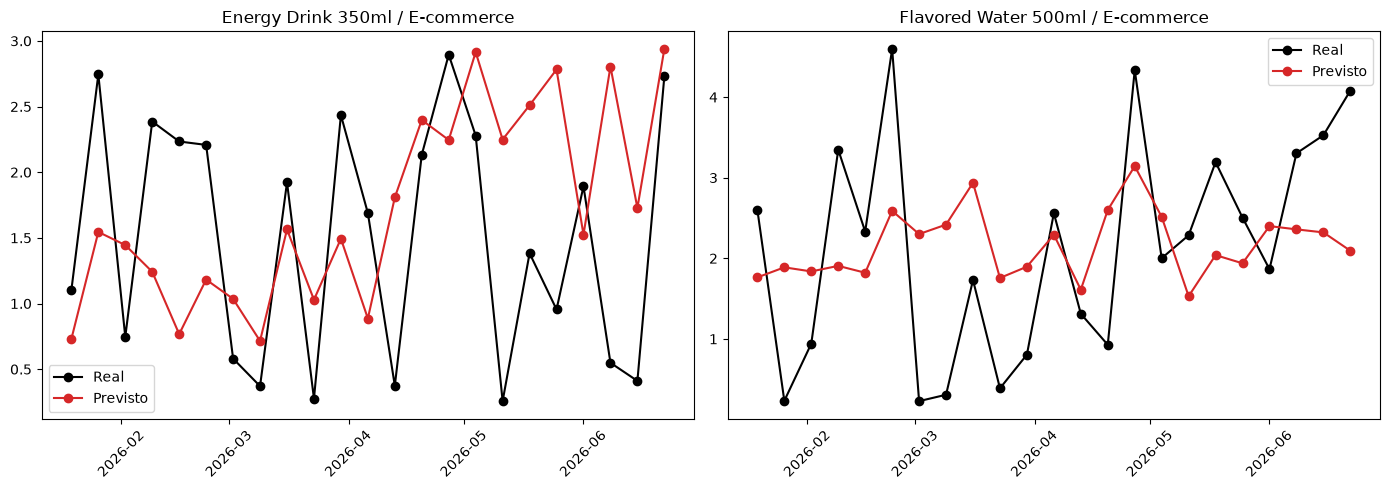

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (product, channel) in zip(axes, problematic):
    sub = recursive_results[(recursive_results.Product == product) & (recursive_results.Channel == channel)]
    ax.plot(sub["Week"], sub["Actual"], marker="o", label="Real", color="black")
    ax.plot(sub["Week"], sub["Predicted"], marker="o", label="Previsto", color="#d62728")
    ax.set_title(f"{product} / {channel}")
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()


## Conclusão

- A accuracy MAPE desses dois SKU-canal era distorcida por semanas de volume muito baixo (< 0.5 ton), onde qualquer erro absoluto pequeno vira um erro percentual gigante.
- Sob WAPE, os dois deixam de ser "casos quebrados" e passam a ter accuracy comparável às demais combinações do portfólio -- ainda abaixo do benchmark, mas dentro de uma faixa razoável, não mais catastrófica.
- **Recomendação prática**: reportar WAPE (em vez de, ou junto com, MAPE) para SKU-canal de baixo volume/alta volatilidade relativa -- é mais representativo do impacto real de negócio, e evita a falsa impressão de que o modelo "não funciona" nesses casos.
